In [1]:
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import pandas as pd
from scipy import stats

energy_mix = pd.ExcelFile("DOE-538281345095_Energy_Mix.xlsx")
electricity_rates = pd.ExcelFile("DOE-538281345095_Electricity_Rates.xlsx")
customer_sales = pd.ExcelFile("DOE-538281345095_Customer_Sales_and_Count_20_25.xlsx")

#check the tabs in excel
print(f"Energy mix: {energy_mix.sheet_names}")
print(f"Electricty rates: {electricity_rates.sheet_names}")
print(f"Customer Sales: {customer_sales.sheet_names}")

Energy mix: ['Residential Non-Lifeline', 'Industrial Rates', 'Commercial Rates', 'NLResidential Rates', 'Sales and Customer Count', 'System Peak Demand', 'Visayas Sub Grid - System Peak', 'Power Generation Mix']
Electricty rates: ['Residential Non-Lifeline', 'Industrial Rates', 'Commercial Rates', 'NLResidential Rates']
Customer Sales: ['Residential Non-Lifeline', 'Sales and Customer Count']


<h2 style="color:red; font-weight:bold">Process the Electric rates

In [2]:
residential_nonlifeline_rates = pd.read_excel("DOE-538281345095_Electricity_Rates.xlsx", sheet_name="Residential Non-Lifeline")
# for residential areas that do not qualify for low-income assistance
# evaluates to NaN
residential_nlrates = pd.read_excel("DOE-538281345095_Electricity_Rates.xlsx", sheet_name="NLResidential Rates") # lifeline(?)
commercial_rates = pd.read_excel("DOE-538281345095_Electricity_Rates.xlsx", sheet_name="Commercial Rates")


#print(residential_nonlifeline_rates.head(), residential_nonlifeline_rates.shape)
print(f"Residential: {residential_nlrates.head()},"
      f" Shape: {residential_nlrates.shape},"
      f" Info: {residential_nlrates.info()},"
      f"Describe: {residential_nlrates.describe(include="all")},"
      f"Number of null: {residential_nlrates.isna().sum()}") # Shape (147, 78), 0 NaN
print(f"Commercial: {commercial_rates.head()}, Shape: {commercial_rates.shape}") # Shape ( 152, 78 )


C:\Users\Cezar Ian\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<class 'pandas.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 78 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   147 non-null    str   
 1   Unnamed: 1   147 non-null    str   
 2   Unnamed: 2   147 non-null    str   
 3   Unnamed: 3   147 non-null    str   
 4   Unnamed: 4   147 non-null    str   
 5   Unnamed: 5   147 non-null    str   
 6   2020         68 non-null     object
 7   Unnamed: 7   68 non-null     object
 8   Unnamed: 8   70 non-null     object
 9   Unnamed: 9   70 non-null     object
 10  Unnamed: 10  71 non-null     object
 11  Unnamed: 11  72 non-null     object
 12  Unnamed: 12  72 non-null     object
 13  Unnamed: 13  71 non-null     object
 14  Unnamed: 14  72 non-null     object
 15  Unnamed: 15  72 non-null     object
 16  Unnamed: 16  71 non-null     object
 17  Unnamed: 17  72 non-null     object
 18  2021         79 non-null     object
 19  Unnamed: 19  79 non-null     object
 20 

In [3]:
#Clean Data
res = residential_nlrates.copy()
res.columns = res.iloc[0]
res = res.iloc[1:].reset_index(drop=True)

com = commercial_rates.copy()
com.columns = com.iloc[0]
com = com.iloc[1:].reset_index(drop=True)
print(com.columns.tolist())
print(res.columns.tolist())

['Distribution Utility', 'ShortHand', 'GRID', 'Region', 'Island', 'EC/PDU', 'Jan-20', 'Feb-20', 'Mar-20', 'Apr-20', 'May-20', 'Jun-20', 'Jul-20', 'Aug-20', 'Sep-20', 'Oct-20', 'Nov-20', 'Dec-20', 'Jan-21', 'Feb-21', 'Mar-21', 'Apr-21', 'May-21', 'Jun-21', 'Jul-21', 'Aug-21', 'Sep-21', 'Oct-21', 'Nov-21', 'Dec-21', 'Jan-22', 'Feb-22', 'Mar-22', 'Apr-22', 'May-22', 'Jun-22', 'Jul-22', 'Aug-22', 'Sep-22', 'Oct-22', 'Nov-22', 'Dec-22', 'Jan-23', 'Feb-23', 'Mar-23', 'Apr-23', 'May-23', 'Jun-23', 'Jul-23', 'Aug-23', 'Sep-23', 'Oct-23', 'Nov-23', 'Dec-23', 'Jan-24', 'Feb-24', 'Mar-24', 'Apr-24', 'May-24', 'Jun-24', 'Jul-24', 'Aug-24', 'Sep-24', 'Oct-24', 'Nov-24', 'Dec-24', 'Jan-25', 'Feb-25', 'Mar-25', 'Apr-25', 'May-25', 'Jun-25', 'Jul-25', 'Aug-25', 'Sep-25', 'Oct-25', 'Nov-25', 'Dec-25']
['Distribution Utility', 'ShortHand', 'GRID', 'Region', 'Island', 'EC/PDU', 'Jan-20', 'Feb-20', 'Mar-20', 'Apr-20', 'May-20', 'Jun-20', 'Jul-20', 'Aug-20', 'Sep-20', 'Oct-20', 'Nov-20', 'Dec-20', 'Jan-21'

In [4]:
id_cols = ["Distribution Utility", "ShortHand", "GRID", "Region", "Island", "EC/PDU"]
month_cols = [
    col for col in res.columns
    if str(col).endswith("-20") or str(col).endswith("-24")  or str(col).endswith("-21")  or str(col).endswith("-25")
]
print(month_cols)


['Jan-20', 'Feb-20', 'Mar-20', 'Apr-20', 'May-20', 'Jun-20', 'Jul-20', 'Aug-20', 'Sep-20', 'Oct-20', 'Nov-20', 'Dec-20', 'Jan-21', 'Feb-21', 'Mar-21', 'Apr-21', 'May-21', 'Jun-21', 'Jul-21', 'Aug-21', 'Sep-21', 'Oct-21', 'Nov-21', 'Dec-21', 'Jan-24', 'Feb-24', 'Mar-24', 'Apr-24', 'May-24', 'Jun-24', 'Jul-24', 'Aug-24', 'Sep-24', 'Oct-24', 'Nov-24', 'Dec-24', 'Jan-25', 'Feb-25', 'Mar-25', 'Apr-25', 'May-25', 'Jun-25', 'Jul-25', 'Aug-25', 'Sep-25', 'Oct-25', 'Nov-25', 'Dec-25']


In [5]:
processed_cols_res = res.melt(
    id_vars= id_cols,
    value_vars = month_cols,
    var_name="Date",
    value_name="Rate",
)

processed_cols_com = com.melt(
    id_vars= id_cols,
    value_vars = month_cols,
    var_name="Date",
    value_name="Rate",
)

processed_cols_res["Customer Class"] = "Residential"
processed_cols_com["Customer Class"] = "Commercial"

rates = pd.concat(
    [processed_cols_res, processed_cols_com],
    ignore_index=True
)

rates["Rate"] = pd.to_numeric(
    rates["Rate"],
    errors="coerce"
)

rates["Date"] = pd.to_datetime(
    rates["Date"],
    format="%b-%y",
    errors="coerce"
)

rates_luzon = rates[
    rates["Island"].astype(str).str.strip().str.lower() == "luzon"
].copy()
print(rates_luzon) #final electricity rates data processed



                                    Distribution Utility  ShortHand      GRID  \
0              ABRA ELECTRIC COOPERATIVE, INC. (ABRECO)      ABRECO   ON-GRID   
1                          ANGELES ELECTRIC CORP. (AEC)         AEC   ON-GRID   
3       ALBAY ELECTRIC COOPERATIVE, INC./ALBAY POWER ...      ALECO   ON-GRID   
7           AURORA ELECTRIC COOPERATIVE, INC. (AURELCO)     AURELCO   ON-GRID   
10       BATANES ELECTRIC COOPERATIVE, INC. (BATANELCO)   BATANELCO  OFF-GRID   
...                                                  ...        ...       ...   
14241                        TARLAC ELECTRIC INC. (TEI)         TEI   ON-GRID   
14242  TABLAS ISLAND ELECTRIC COOPERATIVE, INC. (TIEL...     TIELCO  OFF-GRID   
14243  TICAO ISLAND ELECTRIC COOPERATIVE, INC. (TISEL...    TISELCO  OFF-GRID   
14246  ZAMBALES I ELECTRIC COOPERATIVE, INC. (ZAMECO I)    ZAMECO I   ON-GRID   
14247  ZAMBALES II ELECTRIC COOPERATIVE, INC. (ZAMECO...  ZAMECO II   ON-GRID   

                      Regio

<h2 style="color:red; font-weight:bold">Process Customer sales shit

In [6]:
raw = pd.read_excel("DOE-538281345095_Customer_Sales_and_Count_20_25.xlsx",  sheet_name="Sales and Customer Count",
    header=None)

print(raw.shape)

years = [2020, 2021, 2024, 2025]

customer_classes = [
    "Residential",
    "Commercial",
    "Industrial",
    "Others"
]

records = []

for year in years:

    sales_title = f"Customer Sales as of {year}"
    sales_title_rows = raw.index[
        raw.iloc[:, 1].astype(str).str.strip() == sales_title
    ]

    customer_title = f"Number of Customer as of {year}"
    customer_title_rows = raw.index[
        raw.iloc[:, 1].astype(str).str.strip() == customer_title
    ]

    if len(sales_title_rows) == 0:
        print(f"Sales section not found for {year}")
        continue

    if len(customer_title_rows) == 0:
        print(f"Customer section not found for {year}")
        continue

    sales_title_row = sales_title_rows[0]
    customer_title_row = customer_title_rows[0]

    sales_start = sales_title_row + 2

    customer_start = customer_title_row + 2

    for i, customer_class in enumerate(customer_classes):

        sales_row = sales_start + i
        customer_row = customer_start + i

        for month_num in range(1, 13):

            sales_value = raw.iloc[sales_row, month_num + 1]
            customer_value = raw.iloc[customer_row, month_num + 1]

            records.append({
                "Year": year,
                "Month": month_num,
                "Customer Class": customer_class,
                "Sales": pd.to_numeric(
                    sales_value,
                    errors="coerce"
                ),
                "Customer Count": pd.to_numeric(
                    customer_value,
                    errors="coerce"
                )
            })

sales_count_clean = pd.DataFrame(records)

print(sales_count_clean.head(20))
print(sales_count_clean.shape)


(101, 15)
    Year  Month Customer Class      Sales  Customer Count
0   2020      1    Residential  2507513.0               0
1   2020      2    Residential  2373081.0               0
2   2020      3    Residential  2413511.0               0
3   2020      4    Residential  2721300.0               0
4   2020      5    Residential  3405712.0               0
5   2020      6    Residential  3484903.0               0
6   2020      7    Residential  3027694.0               0
7   2020      8    Residential  2953173.0               0
8   2020      9    Residential  3102593.0               0
9   2020     10    Residential  2868256.0               0
10  2020     11    Residential  2728934.0               0
11  2020     12    Residential  2704915.0               0
12  2020      1     Commercial  2035222.0               0
13  2020      2     Commercial  2072947.0               0
14  2020      3     Commercial  1892171.0               0
15  2020      4     Commercial  1580908.0               0
16  

In [7]:
sales_count_clean["Date"] = pd.to_datetime(
    sales_count_clean["Year"].astype(str)
    + "-"
    + sales_count_clean["Month"].astype(str)
    + "-01"
)
# Sort
sales_count_final = sales_count_clean.sort_values(
    ["Date", "Customer Class"]
).reset_index(drop=True)

print(sales_count_final.head())
print(sales_count_final.tail())
print(sales_count_final["Year"].value_counts().sort_index())



   Year  Month Customer Class      Sales  Customer Count       Date
0  2020      1     Commercial  2035222.0               0 2020-01-01
1  2020      1     Industrial  2165032.0               0 2020-01-01
2  2020      1         Others   223778.0               0 2020-01-01
3  2020      1    Residential  2507513.0               0 2020-01-01
4  2020      2     Commercial  2072947.0               0 2020-02-01
     Year  Month Customer Class       Sales  Customer Count       Date
187  2025     11    Residential  3348754.35        20706258 2025-11-01
188  2025     12     Commercial  1765351.33         1586850 2025-12-01
189  2025     12     Industrial   804902.27          187773 2025-12-01
190  2025     12         Others   478473.32          382524 2025-12-01
191  2025     12    Residential  3150552.68        20843777 2025-12-01
Year
2020    48
2021    48
2024    48
2025    48
Name: count, dtype: int64


In [8]:
philippine_sales = sales_count_final[
    sales_count_final["Customer Class"].isin(
        ["Residential", "Commercial"]
    )
].copy()
print(philippine_sales["Customer Class"].value_counts())
#final sales is philippine_sales
annual_sales = (
    philippine_sales
    .groupby(["Year", "Customer Class"])["Sales"]
    .sum()
    .reset_index()
)

print(annual_sales)

Customer Class
Commercial     48
Residential    48
Name: count, dtype: int64
   Year Customer Class        Sales
0  2020     Commercial  20727103.00
1  2020    Residential  34291585.00
2  2021     Commercial  21118783.00
3  2021    Residential  34980664.00
4  2024     Commercial  28032924.00
5  2024    Residential  41205378.00
6  2025     Commercial  21422900.14
7  2025    Residential  40022203.93


<h2 style="color:red; font-weight:bold">Process Energy Mix

In [9]:
energy_file = pd.read_excel("DOE-538281345095_Energy_Mix.xlsx", header=None, sheet_name="Power Generation Mix")

print(energy_file.shape)
print(energy_file.head(20))

(102, 28)
                                                  0         1         2   \
0                               Department of Energy                       
1                              2024 POWER STATISTICS       NaN       NaN   
2     Gross Power Generation per Grid, by Plant Type       NaN       NaN   
3                                             In MWh                       
4                                                                          
5                                              LUZON      2003      2004   
6                   Generation per Technology (Grid)                       
7                                               Coal  14351121  15548335   
8                                          Oil-based   3595860   4590814   
9                                     Combined Cycle    438755    738437   
10                                            Diesel   2317101   2688194   
11                                       Gas Turbine      1737       183   
12

In [10]:
for i in range(len(energy_file)):
    row_text = " ".join(
        map(str, energy_file.iloc[i].tolist())
    )

    if "LUZON" in row_text.upper():
        print(i, row_text)

5 LUZON 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 % Share - 2025 nan nan nan
60 Luzon 37534630 39853911 40626730 41241457 43619911 44199534 44974855 50264725 50017259 52312426 54819517 56766481 60112863 66497549 68512419 72728369 76176710 72418709 75242541 79820536 83290439 90269376 85945490.35 0.7055444714075623 nan   nan
66 Luzon                                     1302991 1430583 1535520 1630613   0.772     nan


In [11]:
years = {
    "2020": 18,
    "2021": 19,
    "2024": 22,
    "2025": 23
}

top_level_sources = [
    "Coal",
    "Oil-based",
    "Natural Gas",
    "Renewable Energy (RE)"
]

energy_mix_luzon = energy_file.iloc[7:15, [0, 18, 19, 22, 23]].copy()

energy_mix_luzon.columns = [
    "Energy Source",
    "2020",
    "2021",
    "2024",
    "2025"
]

energy_mix_luzon["Energy Source"] = (
    energy_mix_luzon["Energy Source"]
    .astype(str)
    .str.strip()
)

for year in ["2020", "2021", "2024", "2025"]:
    energy_mix_luzon[year] = pd.to_numeric(
        energy_mix_luzon[year],
        errors="coerce"
    )

energy_mix_luzon = energy_mix_luzon[
    energy_mix_luzon["Energy Source"].isin(top_level_sources)
].copy()

print(energy_mix_luzon.to_string(index=False))

        Energy Source     2020     2021       2024        2025
                 Coal 40575727 43133237 57069815.0 48841547.75
            Oil-based  1804176   996287   602894.0   181079.18
          Natural Gas 19496927 19059682 18046729.0 21269050.26
Renewable Energy (RE) 10541880 12053335 14549938.0 15653813.16


In [12]:
total_generation = {
    "2020": 72418709,
    "2021": 75242541,
    "2024": 90269376,
    "2025": 85945490.35
}

for year in ["2020", "2021", "2024", "2025"]:
    energy_mix_luzon[f"Share {year} (%)"] = (
        energy_mix_luzon[year]
        / total_generation[year]
        * 100
    )

print(
    energy_mix_luzon.round(3).to_string(index=False)
)

        Energy Source     2020     2021       2024        2025  Share 2020 (%)  Share 2021 (%)  Share 2024 (%)  Share 2025 (%)
                 Coal 40575727 43133237 57069815.0 48841547.75          56.029          57.326          63.222          56.829
            Oil-based  1804176   996287   602894.0   181079.18           2.491           1.324           0.668           0.211
          Natural Gas 19496927 19059682 18046729.0 21269050.26          26.923          25.331          19.992          24.747
Renewable Energy (RE) 10541880 12053335 14549938.0 15653813.16          14.557          16.019          16.118          18.214


In [13]:
energy_mix_final = energy_mix_luzon.melt(
    id_vars="Energy Source",
    value_vars=[
        "Share 2020 (%)",
        "Share 2021 (%)",
        "Share 2024 (%)",
        "Share 2025 (%)"
    ],
    var_name="Year",
    value_name="Share"
)

energy_mix_final["Year"] = (
    energy_mix_final["Year"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

print(energy_mix_final.to_string(index=False))

        Energy Source  Year     Share
                 Coal  2020 56.029343
            Oil-based  2020  2.491312
          Natural Gas  2020 26.922500
Renewable Energy (RE)  2020 14.556846
                 Coal  2021 57.325599
            Oil-based  2021  1.324101
          Natural Gas  2021 25.330992
Renewable Energy (RE)  2021 16.019309
                 Coal  2024 63.221679
            Oil-based  2024  0.667883
          Natural Gas  2024 19.992083
Renewable Energy (RE)  2024 16.118354
                 Coal  2025 56.828517
            Oil-based  2025  0.210691
          Natural Gas  2025 24.747139
Renewable Energy (RE)  2025 18.213653


### HOURLY DEMAND
:cry

In [14]:
hourly_file = pd.read_excel("Hourly-Demand.xlsx", header=None)

headers = hourly_file.iloc[1].copy()

headers.iloc[0] = "Date"

headers = headers.iloc[:25]

hourly_wide = hourly_file.iloc[2:, :25].copy()

hourly_wide.columns = headers

print(hourly_wide, headers)


1                    Date            1          2.0          3.0          4.0  \
2     2013-01-01 00:00:00         4303  3918.000000  3709.000000  3529.000000   
3     2013-01-02 00:00:00         3657  3545.000000  3437.000000  3373.000000   
4     2013-01-03 00:00:00         4446  4273.000000  4153.000000  4160.000000   
5     2013-01-04 00:00:00         4734  4509.000000  4428.000000  4349.000000   
6     2013-01-05 00:00:00         4807  4688.000000  4552.000000  4421.000000   
...                   ...          ...          ...          ...          ...   
4745  2025-12-27 00:00:00   7726.99707  7481.459961  7246.086914  7078.268555   
4746  2025-12-28 00:00:00  7924.777344  7744.607910  7204.947754  7184.740234   
4747  2025-12-29 00:00:00  7988.254395  7660.505371  7393.287109  7216.661133   
4748  2025-12-30 00:00:00  7923.902344  7571.903320  7320.807129  7116.115234   
4749  2025-12-31 00:00:00  7672.368164  7380.392090  7122.932129  6942.002930   

1             5.0          

In [15]:
hourly_wide["Date"] = pd.to_datetime(
    hourly_wide["Date"],
    errors="coerce"
)

hourly_wide = hourly_wide.dropna(
    subset=["Date"]
).copy()

hour_columns = list(range(1, 25))

for hour in hour_columns:
    hourly_wide[hour] = pd.to_numeric(
        hourly_wide[hour],
        errors="coerce"
    )

hourly_wide["Year"] = hourly_wide["Date"].dt.year
hourly_wide["Month"] = hourly_wide["Date"].dt.month
hourly_wide["Day"] = hourly_wide["Date"].dt.day
hourly_wide["Day_of_Week"] = (
    hourly_wide["Date"].dt.day_name()
)

study_years = [
    2020,
    2021,
    2024,
    2025
]

hourly_wide = hourly_wide[
    hourly_wide["Year"].isin(study_years)
].copy()


In [16]:
hourly_demand = hourly_wide.melt(
    id_vars=[
        "Date",
        "Year",
        "Month",
        "Day",
        "Day_of_Week"
    ],
    value_vars=hour_columns,
    var_name="Hour",
    value_name="Demand_MW"
)


hourly_demand["Hour"] = pd.to_numeric(
    hourly_demand["Hour"],
    errors="coerce"
)

hourly_demand["Demand_MW"] = pd.to_numeric(
    hourly_demand["Demand_MW"],
    errors="coerce"
)

hourly_demand = hourly_demand.dropna(
    subset=["Hour", "Demand_MW"]
).copy()


print(
    "Processed hourly observations:",
    len(hourly_demand)
)

display(hourly_demand.head(24))

Processed hourly observations: 35088


,Date,Year,Month,Day,Day_of_Week,Hour,Demand_MW
0,2020-01-01,2020,1,1,Wednesday,1,6158.0
1,2020-01-02,2020,1,2,Thursday,1,5759.0
2,2020-01-03,2020,1,3,Friday,1,6476.0
3,2020-01-04,2020,1,4,Saturday,1,6574.0
4,2020-01-05,2020,1,5,Sunday,1,6685.0
5,2020-01-06,2020,1,6,Monday,1,6599.0
6,2020-01-07,2020,1,7,Tuesday,1,7057.0
7,2020-01-08,2020,1,8,Wednesday,1,7113.0
8,2020-01-09,2020,1,9,Thursday,1,7083.0
9,2020-01-10,2020,1,10,Friday,1,7015.0


<h2 style="color:red; font-weight:bold">Comparison HERE</h2>

In [17]:

hourly_shape_year = (
    hourly_demand
    .groupby(
        ["Year", "Hour"],
        as_index=False
    )
    .agg(
        Average_Demand_MW=("Demand_MW", "mean"),
        Maximum_Demand_MW=("Demand_MW", "max"),
        Minimum_Demand_MW=("Demand_MW", "min")
    )
)

display(hourly_shape_year)

,Year,Hour,Average_Demand_MW,Maximum_Demand_MW,Minimum_Demand_MW
0,2020,1,7249.606557,8820.00000,4366.000000
1,2020,2,6999.426230,8476.00000,3516.000000
2,2020,3,6775.172131,8197.00000,2912.000000
3,2020,4,6610.289617,7933.00000,2759.000000
4,2020,5,6563.786885,7831.00000,2694.000000
...,...,...,...,...,...
91,2025,20,10551.173301,12840.90039,6636.505371
92,2025,21,10408.675032,12806.68262,6385.091309
93,2025,22,10092.319519,12600.67676,6134.700684
94,2025,23,9692.321126,12266.91699,5785.765137


In [18]:
peak_idx = (
    hourly_demand
    .groupby("Year")["Demand_MW"]
    .idxmax()
)

annual_peak = (
    hourly_demand
    .loc[peak_idx]
    .sort_values("Year")
    [
        [
            "Year",
            "Date",
            "Hour",
            "Demand_MW"
        ]
    ]
    .rename(
        columns={
            "Demand_MW": "Peak_Demand_MW"
        }
    )
    .reset_index(drop=True)
)

display(annual_peak)

,Year,Date,Hour,Peak_Demand_MW
0,2020,2020-03-09,14,11050.00000
1,2021,2021-05-28,14,11599.00000
2,2024,2024-04-24,15,13957.00000
3,2025,2025-04-23,15,13765.03711


In [19]:
#energy_mix_final
#philippine_sales
#rates_luzon
WFH_YEARS = [2020, 2021]
OFFICE_YEARS = [2024, 2025]
CUSTOMER_CLASSES = ["Residential", "Commercial"]


print(energy_mix_final.head(20))
print(philippine_sales)
print(rates_luzon)

            Energy Source  Year      Share
0                    Coal  2020  56.029343
1               Oil-based  2020   2.491312
2             Natural Gas  2020  26.922500
3   Renewable Energy (RE)  2020  14.556846
4                    Coal  2021  57.325599
5               Oil-based  2021   1.324101
6             Natural Gas  2021  25.330992
7   Renewable Energy (RE)  2021  16.019309
8                    Coal  2024  63.221679
9               Oil-based  2024   0.667883
10            Natural Gas  2024  19.992083
11  Renewable Energy (RE)  2024  16.118354
12                   Coal  2025  56.828517
13              Oil-based  2025   0.210691
14            Natural Gas  2025  24.747139
15  Renewable Energy (RE)  2025  18.213653
     Year  Month Customer Class       Sales  Customer Count       Date
0    2020      1     Commercial  2035222.00               0 2020-01-01
3    2020      1    Residential  2507513.00               0 2020-01-01
4    2020      2     Commercial  2072947.00             

In [20]:
hourly_demand["Work_Mode"] = "Other"

hourly_demand.loc[
    hourly_demand["Year"].isin(WFH_YEARS),
    "Work_Mode"
] = "WFH"

hourly_demand.loc[
    hourly_demand["Year"].isin(OFFICE_YEARS),
    "Work_Mode"
] = "Office"


# Keep only the two study scenarios
hourly_demand = hourly_demand[
    hourly_demand["Work_Mode"].isin(["WFH", "Office"])
].copy()


display(
    hourly_demand[
        ["Date", "Year", "Hour", "Demand_MW", "Work_Mode"]
    ].head()
)

,Date,Year,Hour,Demand_MW,Work_Mode
0,2020-01-01,2020,1,6158.0,WFH
1,2020-01-02,2020,1,5759.0,WFH
2,2020-01-03,2020,1,6476.0,WFH
3,2020-01-04,2020,1,6574.0,WFH
4,2020-01-05,2020,1,6685.0,WFH


In [21]:

work_mode_hourly = (
    hourly_demand
    .groupby(
        ["Work_Mode", "Hour"],
        as_index=False
    )
    .agg(
        Average_Demand_MW=("Demand_MW", "mean"),
        Maximum_Demand_MW=("Demand_MW", "max"),
        Minimum_Demand_MW=("Demand_MW", "min")
    )
)

display(work_mode_hourly)

,Work_Mode,Hour,Average_Demand_MW,Maximum_Demand_MW,Minimum_Demand_MW
0,Office,1,8973.251928,11358.00000,5466.091797
1,Office,2,8667.983053,10988.00000,5322.729980
2,Office,3,8398.316671,10578.77832,5159.294434
3,Office,4,8243.421578,10578.77832,5147.509277
4,Office,5,8292.563401,10578.77832,5191.838379
5,Office,6,8336.200452,10578.77832,5454.535156
6,Office,7,8432.636219,10578.77832,5774.753906
7,Office,8,9114.382002,11160.00000,6157.731445
8,Office,9,9809.784060,11926.00000,6330.000000
9,Office,10,10388.624911,12592.00000,6529.435547


In [22]:
#hypothetical customer count based on annual growth for 2020-2021

customer_data = (
    philippine_sales[
        philippine_sales["Year"].isin([2024, 2025])
        & philippine_sales["Customer Class"].isin(
            ["Residential", "Commercial"]
        )
    ]
    .groupby(["Year", "Customer Class"])["Customer Count"]
    .sum()
    .reset_index()
)

customer_growth = {}

for customer_class in ["Residential", "Commercial"]:

    data = (
        customer_data[
            customer_data["Customer Class"] == customer_class
        ]
        .set_index("Year")
    )

    growth = (
        data.loc[2025, "Customer Count"]
        / data.loc[2024, "Customer Count"]
    ) - 1

    customer_growth[customer_class] = growth

hypothetical_customers = []

for customer_class in ["Residential", "Commercial"]:

    data = (
        customer_data[
            customer_data["Customer Class"] == customer_class
        ]
        .set_index("Year")
    )

    growth = customer_growth[customer_class]

    customers_2024 = data.loc[2024, "Customer Count"]

    # Back-calculate from 2024
    customers_2021 = (
        customers_2024 / (1 + growth) ** 3
    )

    customers_2020 = (
        customers_2024 / (1 + growth) ** 4
    )

    hypothetical_customers.extend([
        {
            "Year": 2020,
            "Customer Class": customer_class,
            "Customer Count": customers_2020,
            "Data Type": "Hypothetical"
        },
        {
            "Year": 2021,
            "Customer Class": customer_class,
            "Customer Count": customers_2021,
            "Data Type": "Hypothetical"
        },
        {
            "Year": 2024,
            "Customer Class": customer_class,
            "Customer Count": data.loc[
                2024, "Customer Count"
            ],
            "Data Type": "Actual"
        },
        {
            "Year": 2025,
            "Customer Class": customer_class,
            "Customer Count": data.loc[
                2025, "Customer Count"
            ],
            "Data Type": "Actual"
        }
    ])


hypothetical_customers = pd.DataFrame(
    hypothetical_customers
)


#print("\nCustomer count assumptions:")
#print(
#    hypothetical_customers
#    .round(0)
#    .to_string(index=False)
#)

philippine_sales_model = philippine_sales.copy()

philippine_sales_model.loc[
    philippine_sales_model["Year"].isin([2020, 2021]),
    "Customer Count"
] = np.nan

philippine_sales_model = philippine_sales_model.merge(
    hypothetical_customers[
        ["Year", "Customer Class", "Customer Count", "Data Type"]
    ],
    on=["Year", "Customer Class"],
    how="left",
    suffixes=("", "_Model")
)

philippine_sales_model["Customer Count"] = (
    philippine_sales_model["Customer Count_Model"]
)

philippine_sales_model.drop(
    columns=["Customer Count_Model"],
    inplace=True
)


print(
    philippine_sales_model[
        [
            "Year",
            "Month",
            "Customer Class",
            "Sales",
            "Customer Count",
            "Data Type"
        ]
    ].head(20)
)

    Year  Month Customer Class      Sales  Customer Count     Data Type
0   2020      1     Commercial  2035222.0    1.703741e+07  Hypothetical
1   2020      1    Residential  2507513.0    1.855328e+08  Hypothetical
2   2020      2     Commercial  2072947.0    1.703741e+07  Hypothetical
3   2020      2    Residential  2373081.0    1.855328e+08  Hypothetical
4   2020      3     Commercial  1892171.0    1.703741e+07  Hypothetical
5   2020      3    Residential  2413511.0    1.855328e+08  Hypothetical
6   2020      4     Commercial  1580908.0    1.703741e+07  Hypothetical
7   2020      4    Residential  2721300.0    1.855328e+08  Hypothetical
8   2020      5     Commercial  1257939.0    1.703741e+07  Hypothetical
9   2020      5    Residential  3405712.0    1.855328e+08  Hypothetical
10  2020      6     Commercial  1574425.0    1.703741e+07  Hypothetical
11  2020      6    Residential  3484903.0    1.855328e+08  Hypothetical
12  2020      7     Commercial  1558520.0    1.703741e+07  Hypot

In [23]:
sales = philippine_sales_model[
    philippine_sales_model["Customer Class"].isin(CUSTOMER_CLASSES)
].copy()

sales = sales[
    sales["Year"].isin(WFH_YEARS + OFFICE_YEARS)
].copy()

#print(sales)

def assign_work_mode(row):

    if (
        row["Year"] in WFH_YEARS
        and row["Customer Class"] == "Residential"
    ):
        return "WFH"

    elif (
        row["Year"] in OFFICE_YEARS
        and row["Customer Class"] == "Commercial"
    ):
        return "Office"

    return np.nan


sales["Work_Mode"] = (
    sales.apply(
        assign_work_mode,
        axis=1
    )
)



comparison_sales = sales[
    sales
    ["Work_Mode"].notna()
].copy()

print(comparison_sales)

    Year  Month Customer Class       Sales  Customer Count       Date  \
1   2020      1    Residential  2507513.00    1.855328e+08 2020-01-01   
3   2020      2    Residential  2373081.00    1.855328e+08 2020-02-01   
5   2020      3    Residential  2413511.00    1.855328e+08 2020-03-01   
7   2020      4    Residential  2721300.00    1.855328e+08 2020-04-01   
9   2020      5    Residential  3405712.00    1.855328e+08 2020-05-01   
11  2020      6    Residential  3484903.00    1.855328e+08 2020-06-01   
13  2020      7    Residential  3027694.00    1.855328e+08 2020-07-01   
15  2020      8    Residential  2953173.00    1.855328e+08 2020-08-01   
17  2020      9    Residential  3102593.00    1.855328e+08 2020-09-01   
19  2020     10    Residential  2868256.00    1.855328e+08 2020-10-01   
21  2020     11    Residential  2728934.00    1.855328e+08 2020-11-01   
23  2020     12    Residential  2704915.00    1.855328e+08 2020-12-01   
25  2021      1    Residential  2587535.00    1.965

In [24]:
annual_sales = (
    comparison_sales
    .groupby(
        [
            "Year",
            "Customer Class",
            "Work_Mode"
        ],
        as_index=False
    )
    .agg(
        Annual_Sales_MWh=("Sales", "sum"),
        Average_Customers=("Customer Count", "mean")
    )
)

# Identify whether customer counts are actual or back-cast.
data_type_lookup = (
    hypothetical_customers
    [["Year", "Customer Class", "Data Type"]]
    .drop_duplicates()
)

annual_sales = annual_sales.merge(
    data_type_lookup,
    on=["Year", "Customer Class"],
    how="left"
)

annual_sales["MWh_per_Customer"] = (
    annual_sales["Annual_Sales_MWh"]
    / annual_sales["Average_Customers"]
)

print(annual_sales.round(4).to_string(index=False))

 Year Customer Class Work_Mode  Annual_Sales_MWh  Average_Customers    Data Type  MWh_per_Customer
 2020    Residential       WFH       34291585.00       1.855328e+08 Hypothetical            0.1848
 2021    Residential       WFH       34980664.00       1.965165e+08 Hypothetical            0.1780
 2024     Commercial    Office       28032924.00       1.848798e+07       Actual            1.5163
 2025     Commercial    Office       21422900.14       1.886952e+07       Actual            1.1353


In [25]:
rates = rates_luzon.copy()

rates["Date"] = pd.to_datetime(
    rates["Date"],
    errors="coerce"
)

rates["Year"] = rates["Date"].dt.year

rates = rates[
    rates["Year"].isin(WFH_YEARS + OFFICE_YEARS)
].copy()

# Keep the rate data as observed. Missing rates are left as NaN
# rather than replacing them with an overall mean.
annual_rates = (
    rates
    .dropna(subset=["Rate"])
    .groupby(
        ["Year", "Customer Class"],
        as_index=False
    )
    .agg(
        Average_Rate_PHP_kWh=("Rate", "mean")
    )
)

print("Annual electricity rates:")
print(annual_rates.round(4).to_string(index=False))

Annual electricity rates:
 Year Customer Class  Average_Rate_PHP_kWh
 2020     Commercial                7.8601
 2020    Residential                8.1527
 2021     Commercial                8.4521
 2021    Residential                8.9021
 2024     Commercial                9.9123
 2024    Residential               10.9079
 2025     Commercial                9.1733
 2025    Residential               10.1559


In [26]:
annual_model = annual_sales.merge(
    annual_rates,
    on=["Year", "Customer Class"],
    how="left"
)

annual_model[
    "Estimated_Electricity_Cost_PHP"
] = (
    annual_model["Annual_Sales_MWh"]
    * 1000
    * annual_model["Average_Rate_PHP_kWh"]
)


# Electricity cost per customer
annual_model[
    "Cost_per_Customer_PHP"
] = (
    annual_model[
        "Estimated_Electricity_Cost_PHP"
    ]
    / annual_model["Average_Customers"]
)


print(annual_model) #

   Year Customer Class Work_Mode  Annual_Sales_MWh  Average_Customers  \
0  2020    Residential       WFH       34291585.00       1.855328e+08   
1  2021    Residential       WFH       34980664.00       1.965165e+08   
2  2024     Commercial    Office       28032924.00       1.848798e+07   
3  2025     Commercial    Office       21422900.14       1.886952e+07   

      Data Type  MWh_per_Customer  Average_Rate_PHP_kWh  \
0  Hypothetical          0.184828              8.152667   
1  Hypothetical          0.178004              8.902094   
2        Actual          1.516279              9.912297   
3        Actual          1.135318              9.173335   

   Estimated_Electricity_Cost_PHP  Cost_per_Customer_PHP  
0                    2.795679e+11            1506.837650  
1                    3.114011e+11            1584.605639  
2                    2.778707e+11           15029.803140  
3                    1.965194e+11           10414.650583  


In [27]:
energy = energy_mix_final.copy()

energy = energy[
    energy["Year"].isin(WFH_YEARS + OFFICE_YEARS)
].copy()

energy_pivot = (
    energy
    .pivot_table(
        index="Year",
        columns="Energy Source",
        values="Share",
        aggfunc="sum"
    )
    .reset_index()
)


energy_pivot = energy_pivot.rename(
    columns={
        "Renewable Energy (RE)": "Renewable_Share",
        "Coal": "Coal_Share",
        "Natural Gas": "Natural_Gas_Share",
        "Oil-based": "Oil_Share"
    }
)


for col in [
    "Coal_Share",
    "Natural_Gas_Share",
    "Oil_Share",
    "Renewable_Share"
]:

    if col not in energy_pivot.columns:
        energy_pivot[col] = 0


energy_pivot["Fossil_Share"] = (
    energy_pivot["Coal_Share"]
    + energy_pivot["Natural_Gas_Share"]
    + energy_pivot["Oil_Share"]
)


annual_model = annual_model.merge(
    energy_pivot,
    on="Year",
    how="left"
)

In [28]:
yearly_results = annual_model[
    [
        "Year",
        "Work_Mode",
        "Customer Class",
        "Annual_Sales_MWh",
        "Average_Customers",
        "MWh_per_Customer",
        "Average_Rate_PHP_kWh",
        "Estimated_Electricity_Cost_PHP",
        "Cost_per_Customer_PHP",
        "Renewable_Share",
        "Fossil_Share"
    ]
].sort_values("Year")

print("YEAR-BY-YEAR COMPARISON")
print("==============================================")

print(
    yearly_results.round(4)
    .to_string(index=False)
)


YEAR-BY-YEAR COMPARISON
 Year Work_Mode Customer Class  Annual_Sales_MWh  Average_Customers  MWh_per_Customer  Average_Rate_PHP_kWh  Estimated_Electricity_Cost_PHP  Cost_per_Customer_PHP  Renewable_Share  Fossil_Share
 2020       WFH    Residential       34291585.00       1.855328e+08            0.1848                8.1527                    2.795679e+11              1506.8377          14.5568       85.4432
 2021       WFH    Residential       34980664.00       1.965165e+08            0.1780                8.9021                    3.114011e+11              1584.6056          16.0193       83.9807
 2024    Office     Commercial       28032924.00       1.848798e+07            1.5163                9.9123                    2.778707e+11             15029.8031          16.1184       83.8816
 2025    Office     Commercial       21422900.14       1.886952e+07            1.1353                9.1733                    1.965194e+11             10414.6506          18.2137       81.7863


In [29]:

wfh_data = annual_model[
    annual_model["Work_Mode"] == "WFH"
]

office_data = annual_model[
    annual_model["Work_Mode"] == "Office"
]


# Average annual electricity intensity
wfh_mwh_customer = (
    wfh_data["MWh_per_Customer"].mean()
)

office_mwh_customer = (
    office_data["MWh_per_Customer"].mean()
)


# Average electricity cost per customer
wfh_cost_customer = (
    wfh_data["Cost_per_Customer_PHP"].mean()
)

office_cost_customer = (
    office_data["Cost_per_Customer_PHP"].mean()
)


# Average electricity rate
wfh_rate = (
    wfh_data["Average_Rate_PHP_kWh"].mean()
)

office_rate = (
    office_data["Average_Rate_PHP_kWh"].mean()
)


# Total electricity sales
wfh_total_sales = (
    wfh_data["Annual_Sales_MWh"].sum()
)

office_total_sales = (
    office_data["Annual_Sales_MWh"].sum()
)

wfh_peak_demand = hourly_demand.loc[
    hourly_demand["Year"].isin(WFH_YEARS),
    "Demand_MW"
].max()

office_peak_demand = hourly_demand.loc[
    hourly_demand["Year"].isin(OFFICE_YEARS),
    "Demand_MW"
].max()

peak_change = (
    (office_peak_demand / wfh_peak_demand) - 1
) * 100

In [30]:
comparison = pd.DataFrame({

    "Metric": [
        "Total Electricity Sales (MWh)",
        "Average MWh per Customer",
        "Average Electricity Rate (PHP/kWh)",
        "Average Electricity Cost per Customer (PHP)",
        "Peak Demand (MW)"
    ],

    "WFH_2020_2021": [
        wfh_total_sales,
        wfh_mwh_customer,
        wfh_rate,
        wfh_cost_customer,
        wfh_peak_demand
    ],

    "Office_2024_2025": [
        office_total_sales,
        office_mwh_customer,
        office_rate,
        office_cost_customer,
        office_peak_demand
    ]
})


comparison[
    "Office_vs_WFH_%_Change"
] = (
    comparison["Office_2024_2025"]
    / comparison["WFH_2020_2021"]
    - 1
) * 100


print("WFH VS OFFICE COMPARISON")
print("==============================================")

print(
    comparison.round(2)
    .to_string(index=False)
)


WFH VS OFFICE COMPARISON
                                     Metric  WFH_2020_2021  Office_2024_2025  Office_vs_WFH_%_Change
              Total Electricity Sales (MWh)    69272249.00       49455824.14                  -28.61
                   Average MWh per Customer           0.18              1.33                  630.81
         Average Electricity Rate (PHP/kWh)           8.53              9.54                   11.91
Average Electricity Cost per Customer (PHP)        1545.72          12722.23                  723.06
                           Peak Demand (MW)       11599.00          13957.00                   20.33


In [31]:
energy_index = (
    office_mwh_customer
    / wfh_mwh_customer
) * 100


energy_index_table = pd.DataFrame({

    "Work_Mode": [
        "WFH",
        "Office"
    ],

    "Energy_Intensity_Index": [
        100,
        energy_index
    ]
})

cost_index = (
    office_cost_customer
    / wfh_cost_customer
) * 100


cost_index_table = pd.DataFrame({

    "Work_Mode": [
        "WFH",
        "Office"
    ],

    "Electricity_Cost_Index": [
        100,
        cost_index
    ]
})

ENERGY_WEIGHT = 0.50
COST_WEIGHT = 0.50


burden_index = pd.DataFrame({

    "Work_Mode": [
        "WFH",
        "Office"
    ],

    "Energy_Index": [
        100,
        energy_index
    ],

    "Cost_Index": [
        100,
        cost_index
    ]
})


burden_index[
    "Electricity_Burden_Index"
] = (
    ENERGY_WEIGHT
    * burden_index["Energy_Index"]
    +
    COST_WEIGHT
    * burden_index["Cost_Index"]
)


print("\n==============================================")
print("ELECTRICITY BURDEN INDEX")
print("==============================================")

print(
    burden_index.round(2)
    .to_string(index=False)
)



ELECTRICITY BURDEN INDEX
Work_Mode  Energy_Index  Cost_Index  Electricity_Burden_Index
      WFH        100.00      100.00                    100.00
   Office        730.81      823.06                    776.93


In [32]:
energy_mix_comparison = (
    energy_mix_final
    .pivot_table(
        index="Energy Source",
        columns="Year",
        values="Share",
        aggfunc="sum"
    )
    .reset_index()
)


print("\n==============================================")
print("LUZON ENERGY MIX")
print("==============================================")

print(
    energy_mix_comparison.round(2)
    .to_string(index=False)
)


LUZON ENERGY MIX
        Energy Source  2020  2021  2024  2025
                 Coal 56.03 57.33 63.22 56.83
          Natural Gas 26.92 25.33 19.99 24.75
            Oil-based  2.49  1.32  0.67  0.21
Renewable Energy (RE) 14.56 16.02 16.12 18.21


<h2>Results: WFH vs Office Electricity Model</h2>


In [33]:
print("==============================================")
print("KEY MODEL RESULTS")
print("==============================================")

print(f"WFH average MWh/customer: {wfh_mwh_customer:.6f}")
print(f"Office average MWh/customer: {office_mwh_customer:.6f}")
print(f"Office vs WFH energy intensity: {energy_index:.2f}")
print(f"WFH average cost/customer: PHP {wfh_cost_customer:,.2f}")
print(f"Office average cost/customer: PHP {office_cost_customer:,.2f}")
print(f"Office vs WFH cost index: {cost_index:.2f}")
print("WFH Electricity Burden Index: 100.00")
print("Office Electricity Burden Index: "
    f"{burden_index.loc[burden_index['Work_Mode'] == 'Office', 'Electricity_Burden_Index'].iloc[0]:.2f}")

KEY MODEL RESULTS
WFH average MWh/customer: 0.181416
Office average MWh/customer: 1.325798
Office vs WFH energy intensity: 730.81
WFH average cost/customer: PHP 1,545.72
Office average cost/customer: PHP 12,722.23
Office vs WFH cost index: 823.06
WFH Electricity Burden Index: 100.00
Office Electricity Burden Index: 776.93


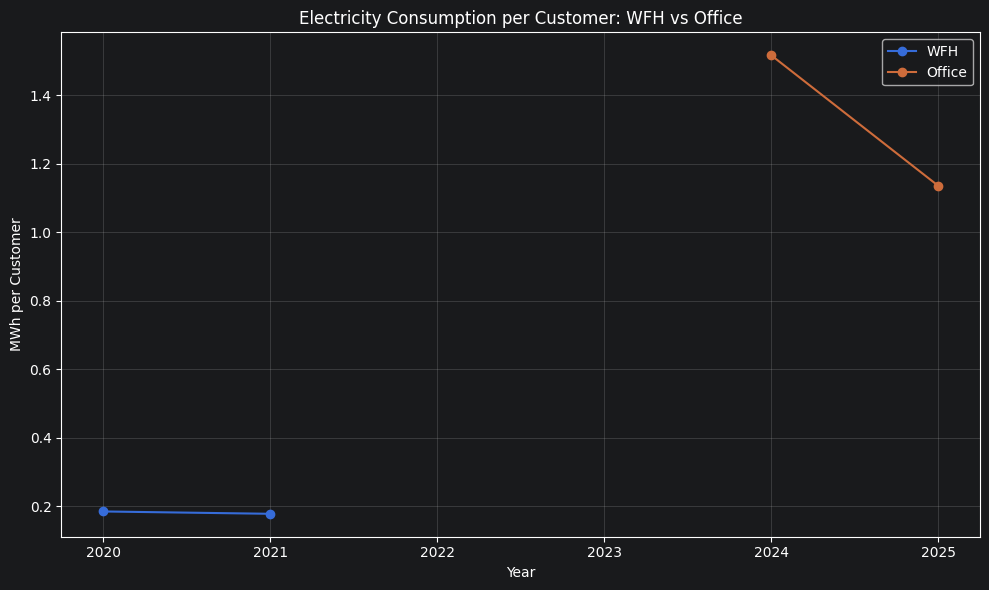

In [34]:
plot_data = annual_model.copy()

plt.figure(figsize=(10, 6))

for mode in ["WFH", "Office"]:

    data = plot_data[
        plot_data["Work_Mode"] == mode
    ]

    plt.plot(
        data["Year"],
        data["MWh_per_Customer"],
        marker="o",
        label=mode
    )

plt.xlabel("Year")
plt.ylabel("MWh per Customer")
plt.title(
    "Electricity Consumption per Customer: WFH vs Office"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


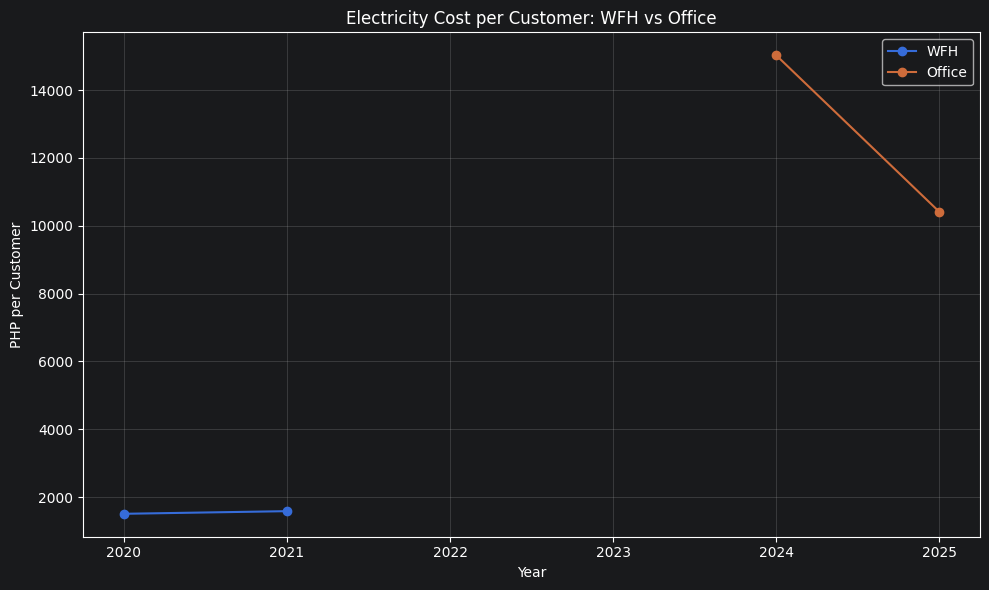

In [35]:
plt.figure(figsize=(10, 6))

for mode in ["WFH", "Office"]:

    data = plot_data[
        plot_data["Work_Mode"] == mode
    ]

    plt.plot(
        data["Year"],
        data["Cost_per_Customer_PHP"],
        marker="o",
        label=mode
    )

plt.xlabel("Year")
plt.ylabel("PHP per Customer")
plt.title(
    "Electricity Cost per Customer: WFH vs Office"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



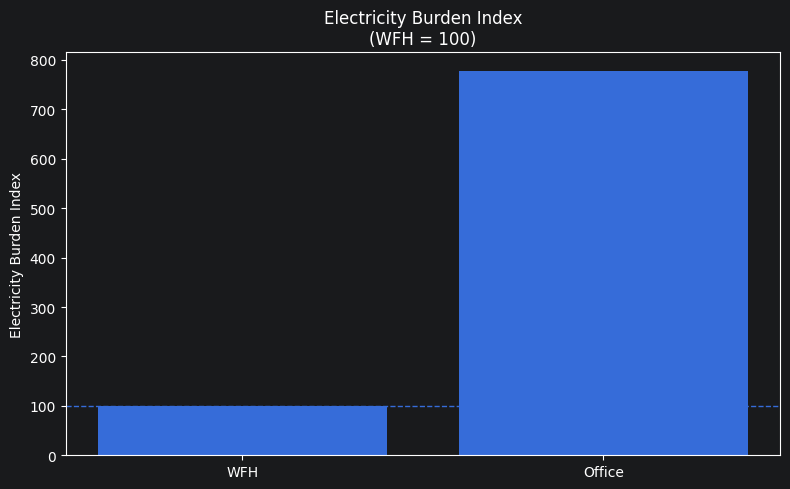

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    burden_index["Work_Mode"],
    burden_index["Electricity_Burden_Index"]
)

plt.axhline(
    100,
    linestyle="--",
    linewidth=1
)

plt.ylabel("Electricity Burden Index")
plt.title(
    "Electricity Burden Index\n(WFH = 100)"
)

plt.tight_layout()
plt.show()


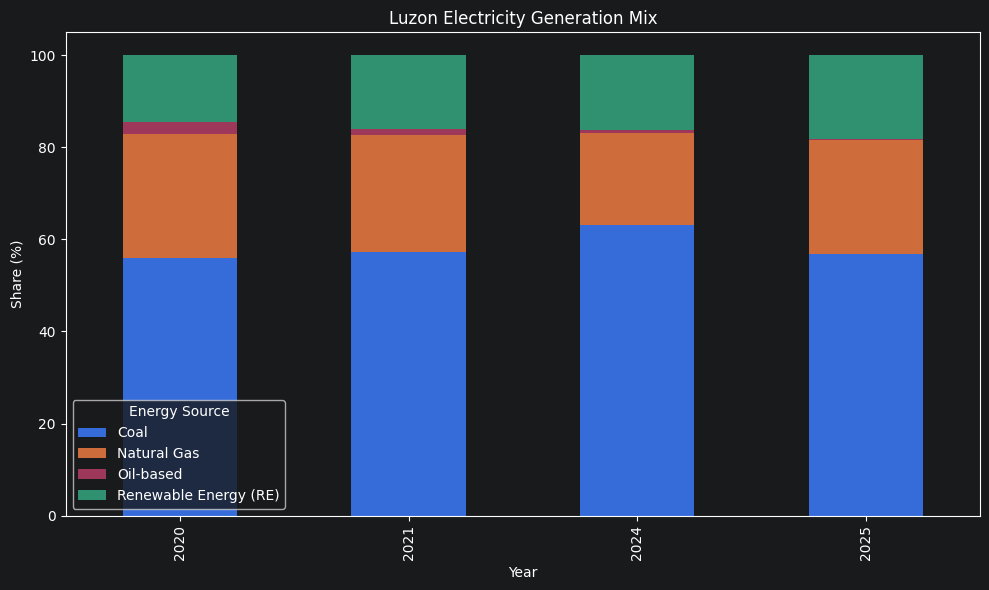

In [37]:
energy_plot = energy_mix_comparison.set_index(
    "Energy Source"
).T

energy_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Year")
plt.ylabel("Share (%)")
plt.title("Luzon Electricity Generation Mix")
plt.legend(title="Energy Source")
plt.tight_layout()
plt.show()

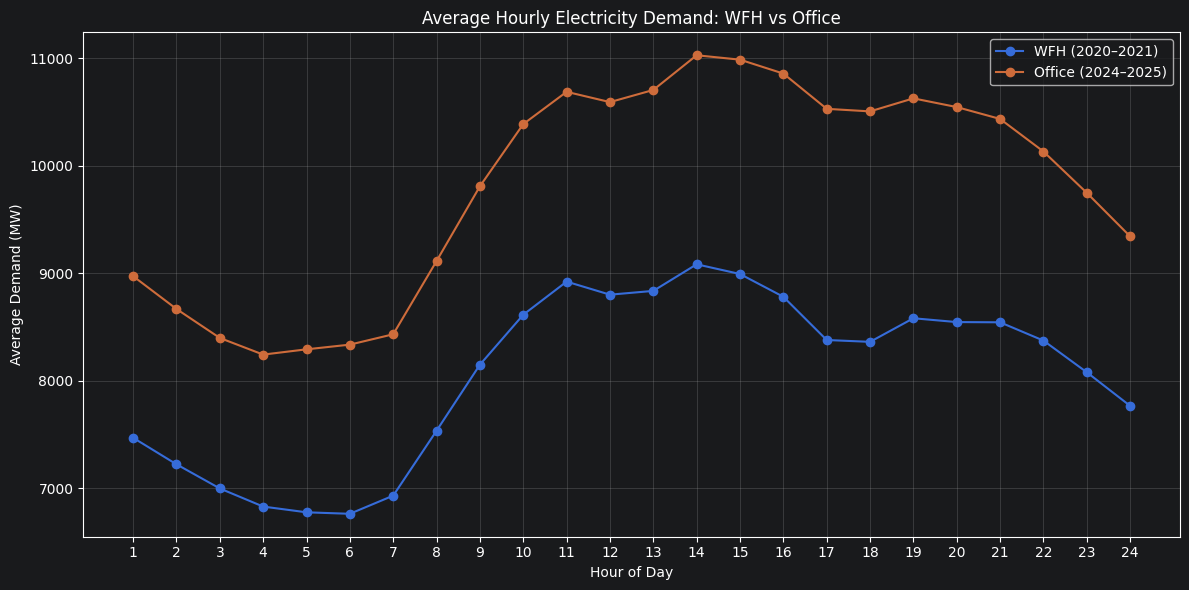

In [38]:
hourly_plot = (
    hourly_demand
    .groupby(["Work_Mode", "Hour"], as_index=False)["Demand_MW"]
    .mean()
)

hourly_plot_pivot = (
    hourly_plot
    .pivot(index="Hour", columns="Work_Mode", values="Demand_MW")
)

plt.figure(figsize=(12, 6))

if "WFH" in hourly_plot_pivot.columns:
    plt.plot(
        hourly_plot_pivot.index,
        hourly_plot_pivot["WFH"],
        marker="o",
        label="WFH (2020–2021)"
    )

if "Office" in hourly_plot_pivot.columns:
    plt.plot(
        hourly_plot_pivot.index,
        hourly_plot_pivot["Office"],
        marker="o",
        label="Office (2024–2025)"
    )

plt.title("Average Hourly Electricity Demand: WFH vs Office")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(1, 25))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Cost-Efficiency Result


In [39]:
if office_cost_customer < wfh_cost_customer:
    lower_cost_scenario = "Office"
elif wfh_cost_customer < office_cost_customer:
    lower_cost_scenario = "WFH"
else:
    lower_cost_scenario = "Equal"

cost_difference = abs(office_cost_customer - wfh_cost_customer)

cost_change_percent = (
    (office_cost_customer / wfh_cost_customer) - 1
) * 100

print("MODEL-BASED COST RESULT")
print("==============================================")
print(f"WFH average cost/customer: PHP {wfh_cost_customer:,.2f}")
print(f"Office average cost/customer: PHP {office_cost_customer:,.2f}")
print(f"Absolute cost difference/customer: PHP {cost_difference:,.2f}")
print(f"Office vs WFH cost change: {cost_change_percent:+.2f}%")
print(f"Lower modeled electricity-cost scenario: {lower_cost_scenario}")
print(f"WFH peak demand: {wfh_peak_demand:,.2f} MW")
print(f"Office peak demand: {office_peak_demand:,.2f} MW")
print(f"Office vs WFH peak-demand change: {peak_change:+.2f}%")

MODEL-BASED COST RESULT
WFH average cost/customer: PHP 1,545.72
Office average cost/customer: PHP 12,722.23
Absolute cost difference/customer: PHP 11,176.51
Office vs WFH cost change: +723.06%
Lower modeled electricity-cost scenario: WFH
WFH peak demand: 11,599.00 MW
Office peak demand: 13,957.00 MW
Office vs WFH peak-demand change: +20.33%


In [40]:
#Clean Data Graph
obs_daily_peak = (
    hourly_demand
    .groupby(["Date", "Work_Mode"], as_index=False)["Demand_MW"].max()
)
obs_wfh_peak = obs_daily_peak.loc[obs_daily_peak["Work_Mode"] == "WFH", "Demand_MW"]
obs_office_peak = obs_daily_peak.loc[obs_daily_peak["Work_Mode"] == "Office", "Demand_MW"]

FIX_CUSTOMER_COUNT = True

if FIX_CUSTOMER_COUNT:
    _avg_cust = (
        philippine_sales[
            philippine_sales["Year"].isin([2024, 2025])
            & philippine_sales["Customer Class"].isin(["Residential", "Commercial"])
        ]
        .groupby(["Year", "Customer Class"])["Customer Count"]
        .mean()
        .reset_index()
    )
    _rows = []
    for _cc in ["Residential", "Commercial"]:
        _d = _avg_cust[_avg_cust["Customer Class"] == _cc].set_index("Year")["Customer Count"]
        _g = _d[2025] / _d[2024] - 1                      # same back-cast method as above
        _rows += [
            {"Year": 2020, "Customer Class": _cc, "Customer Count": _d[2024] / (1 + _g) ** 4},
            {"Year": 2021, "Customer Class": _cc, "Customer Count": _d[2024] / (1 + _g) ** 3},
            {"Year": 2024, "Customer Class": _cc, "Customer Count": _d[2024]},
            {"Year": 2025, "Customer Class": _cc, "Customer Count": _d[2025]},
        ]
    obs_sales = (
        comparison_sales.drop(columns="Customer Count")
        .merge(pd.DataFrame(_rows), on=["Year", "Customer Class"], how="left")
    )
else:
    obs_sales = comparison_sales.copy()

obs_kwh = obs_sales.assign(
    kWh_per_Customer=lambda d: d["Sales"] / d["Customer Count"] * 1000
)[["Year", "Month", "Customer Class", "Work_Mode", "kWh_per_Customer"]]

obs_rates = rates_luzon.dropna(subset=["Rate"]).copy()
obs_rates["Year"] = obs_rates["Date"].dt.year
obs_rates["Month"] = obs_rates["Date"].dt.month

obs_monthly = obs_rates.merge(obs_kwh, on=["Year", "Month", "Customer Class"], how="inner")
obs_monthly["Monthly_Cost"] = obs_monthly["kWh_per_Customer"] * obs_monthly["Rate"]

obs_annual = (
    obs_monthly
    .groupby(["Work_Mode", "Distribution Utility", "Year"])
    .agg(Months=("Month", "nunique"), Annual_Cost=("Monthly_Cost", "sum"))
    .reset_index()
)
obs_annual = obs_annual[obs_annual["Months"] == 12]

obs_wfh_cost = obs_annual.loc[obs_annual["Work_Mode"] == "WFH", "Annual_Cost"]
obs_office_cost = obs_annual.loc[obs_annual["Work_Mode"] == "Office", "Annual_Cost"]

print(f"WFH:    {len(obs_wfh_peak)} days | {len(obs_wfh_cost)} utility-years")
print(f"Office: {len(obs_office_peak)} days | {len(obs_office_cost)} utility-years")

WFH:    731 days | 63 utility-years
Office: 731 days | 91 utility-years


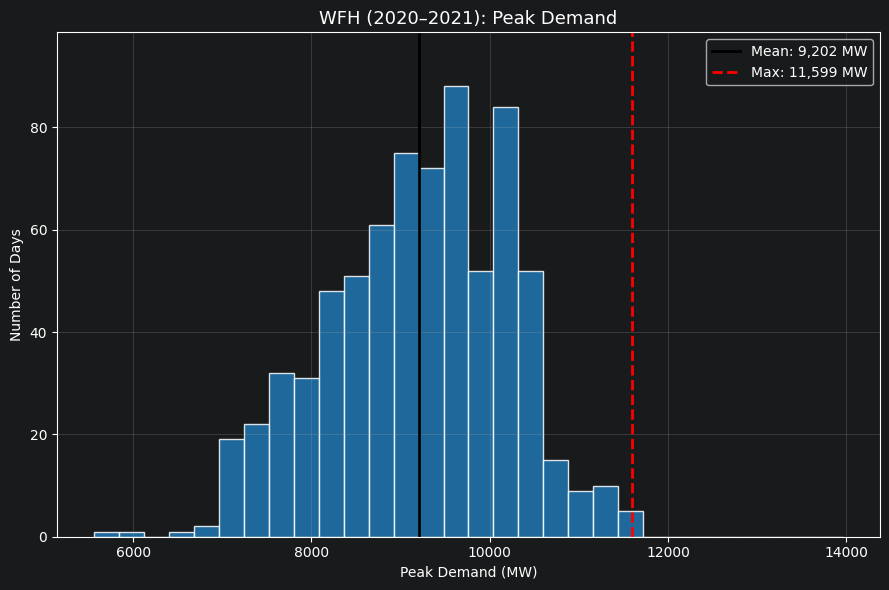

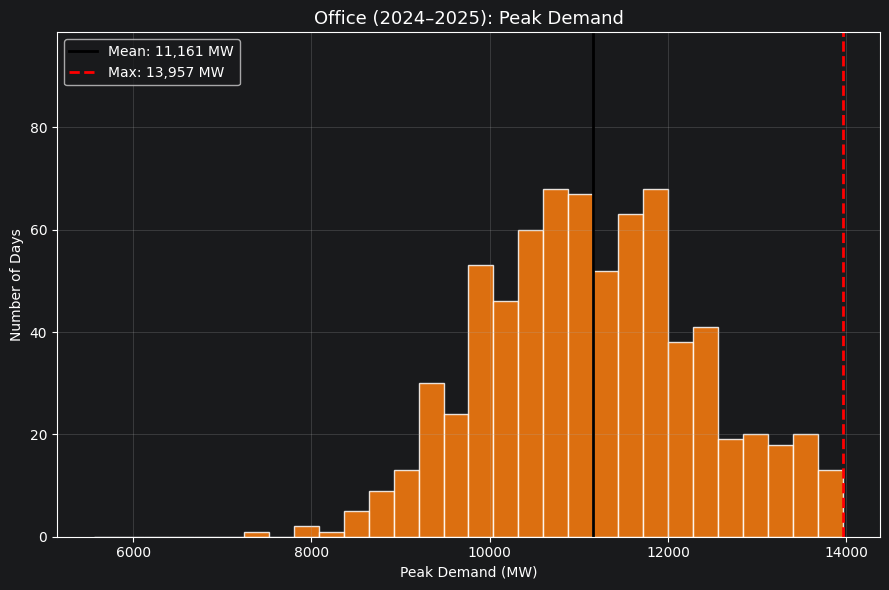

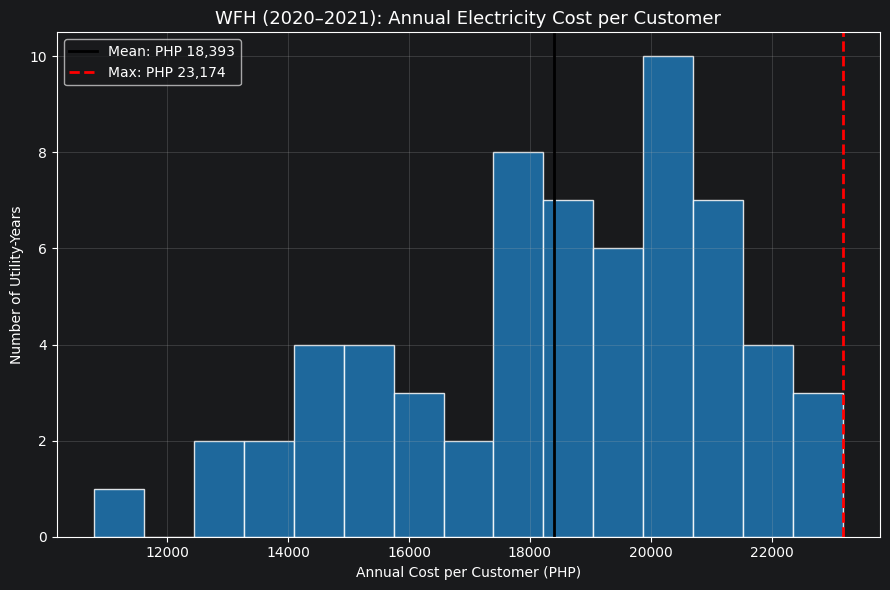

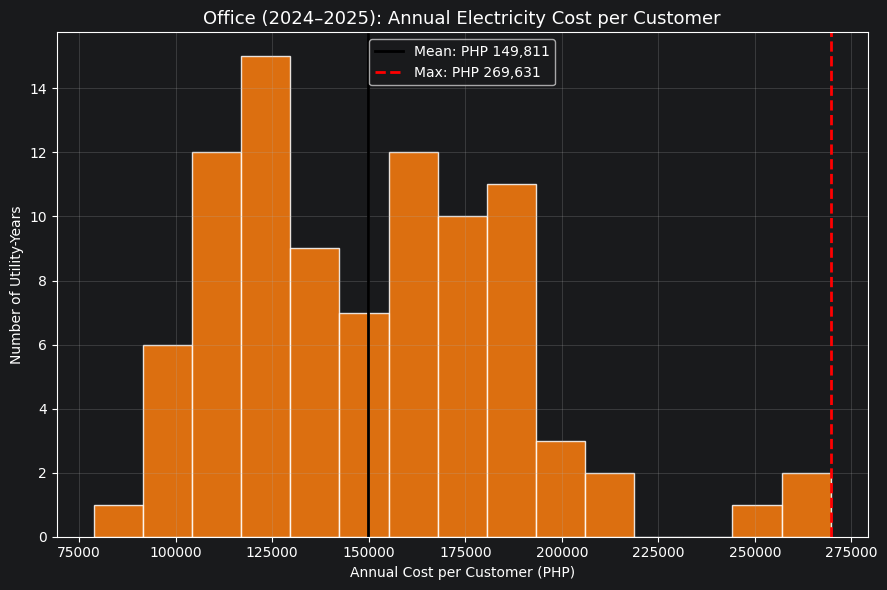

In [41]:
pk_bins_obs = np.linspace(min(obs_wfh_peak.min(), obs_office_peak.min()),
                          max(obs_wfh_peak.max(), obs_office_peak.max()), 31)
pk_ymax_obs = max(np.histogram(obs_wfh_peak, pk_bins_obs)[0].max(),
                  np.histogram(obs_office_peak, pk_bins_obs)[0].max()) * 1.12

def plot_observed_hist(s, color, title, xlabel, ylabel, unit, filename):
    is_peak = unit == "MW"
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.hist(s, bins=pk_bins_obs if is_peak else 15, color=color, alpha=0.85, edgecolor="white")
    fmt = (lambda v: f"{v:,.0f} MW") if is_peak else (lambda v: f"PHP {v:,.0f}")
    ax.axvline(s.mean(), color="black", linewidth=2, label=f"Mean: {fmt(s.mean())}")
    ax.axvline(s.max(), color="red", linestyle="--", linewidth=2, label=f"Max: {fmt(s.max())}")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if is_peak:
        ax.set_ylim(0, pk_ymax_obs)
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.show()

plot_observed_hist(obs_wfh_peak, "tab:blue", "WFH (2020–2021): Peak Demand",
                   "Peak Demand (MW)", "Number of Days", "MW", "graph1_wfh_peak_demand.png")

plot_observed_hist(obs_office_peak, "tab:orange", "Office (2024–2025): Peak Demand",
                   "Peak Demand (MW)", "Number of Days", "MW", "graph2_office_peak_demand.png")

plot_observed_hist(obs_wfh_cost, "tab:blue", "WFH (2020–2021): Annual Electricity Cost per Customer",
                   "Annual Cost per Customer (PHP)", "Number of Utility-Years", "PHP", "graph3_wfh_annual_cost.png")

plot_observed_hist(obs_office_cost, "tab:orange", "Office (2024–2025): Annual Electricity Cost per Customer",
                   "Annual Cost per Customer (PHP)", "Number of Utility-Years", "PHP", "graph4_office_annual_cost.png")

## Monte Carlo Simulations for Predictions


### Peak Demand Simulation


KDE Peak Demand Forecast for 100 Years
WFH Expected Annual Peak (Median): 11,761.87 MW
WFH Extreme Grid Strain (95th): 12,062.62 MW

Office Expected Annual Peak (Median): 14,262.07 MW
Office Extreme Grid Strain (95th): 14,534.19 MW



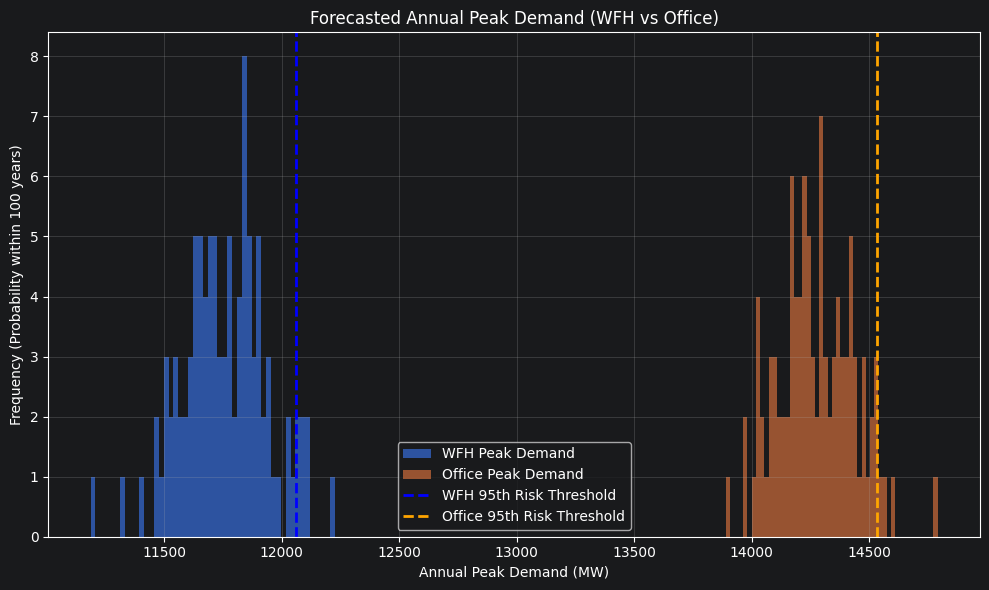

In [42]:
iterations = 100 #years
days_in_year = 365

# isolate the daily peak demands from the hourly dataset
daily_peaks = hourly_demand.groupby(['Year', 'Month', 'Day'])['Demand_MW'].max().reset_index()

#WFH and Office historical daily peaks
wfh_peaks = daily_peaks[daily_peaks['Year'].isin(WFH_YEARS)]['Demand_MW'].dropna()
office_peaks = daily_peaks[daily_peaks['Year'].isin(OFFICE_YEARS)]['Demand_MW'].dropna()

#fit exact non-normal distribution shapes with KDE
wfh_kde = stats.gaussian_kde(wfh_peaks)
office_kde = stats.gaussian_kde(office_peaks)

#10,000 scenarios resampling
sim_wfh_daily = wfh_kde.resample(iterations * days_in_year).reshape(iterations, days_in_year)
sim_office_daily = office_kde.resample(iterations * days_in_year).reshape(iterations, days_in_year)

# worst day of each year
sim_wfh_annual_peaks = np.max(sim_wfh_daily, axis=1)
sim_office_annual_peaks = np.max(sim_office_daily, axis=1)

#
wfh_median_peak = np.median(sim_wfh_annual_peaks)
office_median_peak = np.median(sim_office_annual_peaks)
wfh_95th_peak = np.percentile(sim_wfh_annual_peaks, 95)
office_95th_peak = np.percentile(sim_office_annual_peaks, 95)

print("KDE Peak Demand Forecast for 100 Years")
print(f"WFH Expected Annual Peak (Median): {wfh_median_peak:,.2f} MW")
print(f"WFH Extreme Grid Strain (95th): {wfh_95th_peak:,.2f} MW\n")
print(f"Office Expected Annual Peak (Median): {office_median_peak:,.2f} MW")
print(f"Office Extreme Grid Strain (95th): {office_95th_peak:,.2f} MW\n")

plt.figure(figsize=(10, 6))
plt.hist(sim_wfh_annual_peaks, bins=50, alpha=0.7, label='WFH Peak Demand')
plt.hist(sim_office_annual_peaks, bins=50, alpha=0.7, label='Office Peak Demand')
plt.axvline(wfh_95th_peak, color='blue', linestyle='dashed', linewidth=2, label='WFH 95th Risk Threshold')
plt.axvline(office_95th_peak, color='orange', linestyle='dashed', linewidth=2, label='Office 95th Risk Threshold')
plt.title('Forecasted Annual Peak Demand (WFH vs Office)')
plt.xlabel('Annual Peak Demand (MW)')
plt.ylabel('Frequency (Probability within 100 years)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Cost-Efficiency Simulation


KDE Forecasted Annual Cost Per Customer For 100 Years
WFH Expected Annual Cost (Median): PHP 1,579.09
WFH Worst-Case Cost Budget (95th): PHP 1,734.10

Office Expected Annual Cost (Median): PHP 12,615.43
Office Worst-Case Cost Budget (95th): PHP 14,258.39



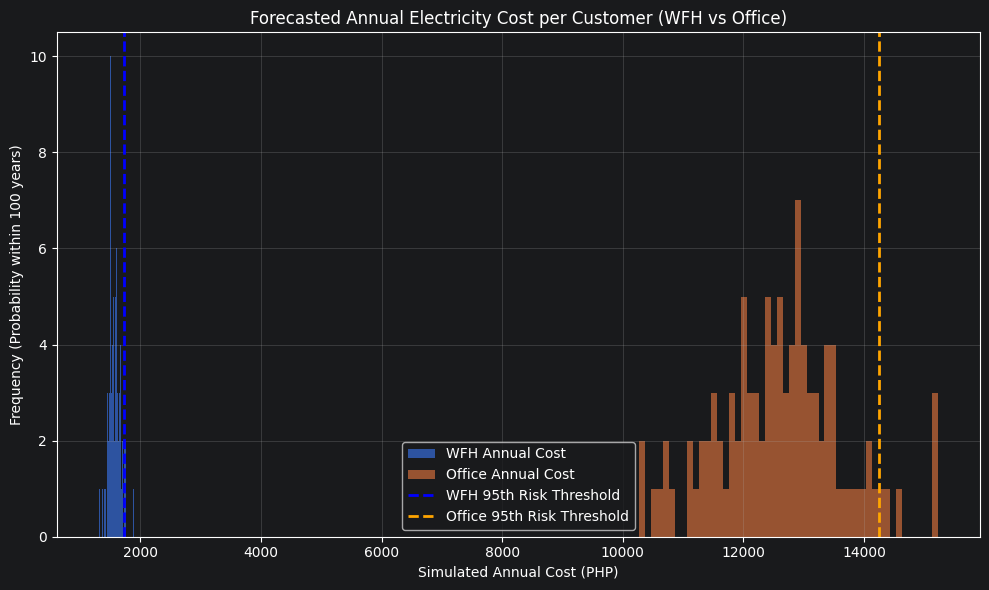

In [43]:
months_in_year = 12
# baseline from sales and rates
wfh_sales = comparison_sales[comparison_sales['Work_Mode'] == 'WFH'].copy()
office_sales = comparison_sales[comparison_sales['Work_Mode'] == 'Office'].copy()

#monthly kwh per customer
wfh_kwh_data = ((wfh_sales['Sales'] / wfh_sales['Customer Count']) * 1000).dropna()
office_kwh_data = ((office_sales['Sales'] / office_sales['Customer Count']) * 1000).dropna()
wfh_rates_data = rates_luzon[(rates_luzon['Customer Class'] == 'Residential') & (rates_luzon['Date'].dt.year.isin(WFH_YEARS))]['Rate'].dropna()
office_rates_data = rates_luzon[(rates_luzon['Customer Class'] == 'Commercial') & (rates_luzon['Date'].dt.year.isin(OFFICE_YEARS))]['Rate'].dropna()

#fit exact non-normal distribution shapes with KDE
wfh_kwh_kde = stats.gaussian_kde(wfh_kwh_data)
office_kwh_kde = stats.gaussian_kde(office_kwh_data)
wfh_rate_kde = stats.gaussian_kde(wfh_rates_data)
office_rate_kde = stats.gaussian_kde(office_rates_data)

# resampling
sim_wfh_kwh = wfh_kwh_kde.resample(iterations * months_in_year).reshape(iterations, months_in_year)
sim_office_kwh = office_kwh_kde.resample(iterations * months_in_year).reshape(iterations, months_in_year)
sim_wfh_rates = wfh_rate_kde.resample(iterations * months_in_year).reshape(iterations, months_in_year)
sim_office_rates = office_rate_kde.resample(iterations * months_in_year).reshape(iterations, months_in_year)

# annual cost
sim_wfh_annual_cost = np.sum(sim_wfh_kwh * sim_wfh_rates, axis=1)
sim_office_annual_cost = np.sum(sim_office_kwh * sim_office_rates, axis=1)

#
wfh_median_cost = np.median(sim_wfh_annual_cost)
office_median_cost = np.median(sim_office_annual_cost)
wfh_95th_cost = np.percentile(sim_wfh_annual_cost, 95)
office_95th_cost = np.percentile(sim_office_annual_cost, 95)

print("KDE Forecasted Annual Cost Per Customer For 100 Years")
print(f"WFH Expected Annual Cost (Median): PHP {wfh_median_cost:,.2f}")
print(f"WFH Worst-Case Cost Budget (95th): PHP {wfh_95th_cost:,.2f}\n")
print(f"Office Expected Annual Cost (Median): PHP {office_median_cost:,.2f}")
print(f"Office Worst-Case Cost Budget (95th): PHP {office_95th_cost:,.2f}\n")

plt.figure(figsize=(10, 6))
plt.hist(sim_wfh_annual_cost, bins=50, alpha=0.7, label='WFH Annual Cost')
plt.hist(sim_office_annual_cost, bins=50, alpha=0.7, label='Office Annual Cost')
plt.axvline(wfh_95th_cost, color='blue', linestyle='dashed', linewidth=2, label='WFH 95th Risk Threshold')
plt.axvline(office_95th_cost, color='orange', linestyle='dashed', linewidth=2, label='Office 95th Risk Threshold')
plt.title('Forecasted Annual Electricity Cost per Customer (WFH vs Office)')
plt.xlabel('Simulated Annual Cost (PHP)')
plt.ylabel('Frequency (Probability within 100 years)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()